# Dependencies

In [1]:
%pip install -U -q 'instructor[vertexai]' 'anthropic[vertex]' google-genai openai langgraph langchain_huggingface langchain-community langchain_experimental httpx sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.9/111.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.2/168.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%pip install -U -q neo4j tenacity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.7/301.7 kB 21.1 MB/s eta 0:00:00


# Credentials

In [3]:
import getpass
import os

DEEPSEEK_API_KEY=getpass.getpass('DeepSeek API Key: ')
DEEPSEEK_BASE_URL="https://api.deepseek.com"


DeepSeek API Key: ··········


In [4]:
PROD_NEO4J_HOST=getpass.getpass('URL for Neo4j: ')
PROD_NEO4J_USER=getpass.getpass('Username for Neo4j: ')
PROD_NEO4J_PASSWORD=getpass.getpass('Password for Neo4j: ')
PROD_NEO4J_DB='neo4j'

URL for Neo4j: ··········
Username for Neo4j: ··········
Password for Neo4j: ··········


In [5]:
NEO4J_HOST=getpass.getpass('URL for Neo4j: ')
NEO4J_USER=getpass.getpass('Username for Neo4j: ')
NEO4J_PASSWORD=getpass.getpass('Password for Neo4j: ')
NEO4J_DB='neo4j'

URL for Neo4j: ··········
Username for Neo4j: ··········
Password for Neo4j: ··········


# Inputs

In [6]:
ontology = """sections:
  Metadata:
  PartI:
    - Business
    - RiskFactor
    - LegalProceeding
    - MineSafety

entities:
  Metadata:
    properties:
      name:
        type: str
        description: Form10K_2023
      type:
        type: str
        description: financial_report
      about:
        type: str
        description: Form 10K Annual report containing company's financial statements and operations
        index: true
      filingDate:
        type: str
        description: Date in YYYY-MM-DD format
      context:
        type: str
        description: Contains high level information about the document processed
        index: true
    relationships:
      ABOUT_COMPANY:
        target: Company
      HAS_PART1:
        target: PartI
  Company:
    properties:
      name:
        type: str
        description: Name of the Company
        unique: true
        required: true
      cik:
        type: str
        description: Cusip Identifier for Company
        unique: true
  PartI:
    relationships:
      HAS_BUSINESS:
        target: Business
      HAS_RISK_FACTOR:
        target: RiskFactor
      HAS_LEGAL_PROCEEDING:
        target: LegalProceeding
      HAS_MINE_SAFETY:
        target: MineSafety
  Business:
    properties:
      description:
        type: str
        description: General business description
      seasonality:
        type: str
        description: Business seasonality patterns
      employees:
        type: int
        description: Number of employees
      regulatoryEnvironment:
        type: str
        description: Regulatory framework description
    relationships:
      HAS_SEGMENT:
        target: BusinessSegment
      HAS_PRODUCT:
        target: Product
      HAS_COMPETITION:
        target: Company
      HAS_RAW_MATERIAL:
        target: RawMaterial
      HAS_INTELLECTUAL_PROPERTY:
        target: IntellectualProperty
  BusinessSegment:
    properties:
      name:
        type: str
        description: Name of the segment
        unique: true
        required: true
  Product:
    properties:
      name:
        type: str
        description: Name of the product
        unique: true
        required: true
  RawMaterial:
    properties:
      name:
        type: str
        description: Name of the raw material
        unique: true
        required: true
  IntellectualProperty:
    properties:
      name:
        type: str
        description: Name of the IntellectualProperty
        unique: true
        required: true
  RiskFactor:
    properties:
      name:
        type: str
        description: Risk factor name
        unique: true
        required: true
      description:
        type: str
        description: General risk description
      potentialImpact:
        type: str
        description: Potential impact of the risk on business
      mitigationStrategy:
        type: str
        description: Risk mitigation strategy
    relationships:
      HAS_RISK_CATEGORY:
        target: RiskCategory
  RiskCategory:
    properties:
      name:
        type: str
        description: Name of the Risk Category
        unique: true
        required: true
  LegalProceeding:
    properties:
      name:
        type: str
        description: Legal proceeding name
        unique: true
        required: true
      description:
        type: str
        description: Legal case description
      jurisdiction:
        type: str
        description: Legal jurisdiction
      status:
        type: str
        description: Current proceeding status
      potentialLiability:
        type: str
        description: Potential financial liability
      expectedResolution:
        type: str
        description: Expected resolution timeline
  MineSafety:
    properties:
      name:
        type: str
        description: Mine safety record name
        unique: true
        required: true
      violations:
        type: str
        description: Number of safety violations
      assessments:
        type: str
        description: Number of financial assessments or penalties
    relationships:
      HAS_CITATION:
        target: Citation
  Citation:
    properties:
      name:
        type: str
        description: Citation name
        unique: true
        required: true
      description:
        type: str
        description: Citation description
"""

In [7]:
import json
import requests

def extract_part1_content(data):
    """
    Extract and format content from PART I section recursively.

    Args:
        data (dict): Input dictionary containing document structure

    Returns:
        str: Formatted content from PART I section
    """
    def recursive_extract(content_obj, accumulated_text=""):
        """
        Recursively extract content from nested structure.

        Args:
            content_obj (dict): Content object to process
            accumulated_text (str): Accumulated text from previous recursions

        Returns:
            str: Combined formatted text
        """
        # Handle title and text if present
        txt = ''
        if content_obj.get('text'):
          txt = content_obj['text'].strip()

        if content_obj.get('title') :
            accumulated_text += f"Title: {content_obj['title']}\n  "
        if txt != '':
          accumulated_text += f"{txt}\n<!>\n"

        # Process nested content if present
        if content_obj.get('content'):
            if isinstance(content_obj['content'], list):
                for item in content_obj['content']:
                    accumulated_text += recursive_extract(item)
            elif isinstance(content_obj['content'], dict):
                accumulated_text += recursive_extract(content_obj['content'])

        return accumulated_text

    # Find PART I in the document
    try:
        document = data['document'][0]
        if 'content' in document:
            for section in document['content']:
                if section.get('title') == 'PART I':
                    return recursive_extract(section).strip('<!>\n')
        return "PART I section not found"
    except (KeyError, IndexError):
        return "Invalid document structure"

def fetch_form10k_part1():

    github_api_url = f"https://api.github.com/repos/ezhilvendhan/blogs/contents/eval-graph-creation/data"
    try:
        response = requests.get(github_api_url)
        response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)

        files = response.json()
        all_form10k_part1 = []
        for file in files:
            if file["type"] == "file" and file["name"].endswith(".json"):
                file_url = file["download_url"]
                file_response = requests.get(file_url)
                file_response.raise_for_status()
                try:
                    whole_form10k = json.loads(file_response.text)
                    part1 = extract_part1_content(whole_form10k)
                    all_form10k_part1.append(part1)
                except json.JSONDecodeError:
                    print(f"Warning: Skipping invalid JSON file: {file['name']}")

        return all_form10k_part1

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from GitHub: {e}")
        return []

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return []

In [8]:
all_form10k = fetch_form10k_part1()
len(all_form10k)

10

# Prepare LLM Calls

In [9]:
import instructor
from openai import OpenAI
from pydantic import BaseModel
from tenacity import Retrying, stop_after_attempt, wait_fixed
import getpass

def call_llm(messages, response_model):
  MODEL = 'deepseek-chat'

  client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url=DEEPSEEK_BASE_URL)
  llm = instructor.from_openai(client, mode=instructor.Mode.JSON)
  return llm.chat.completions.create(
      model=MODEL,
      messages=messages,
      response_model=response_model,
      max_tokens=8000,
      max_retries=Retrying(
        stop=stop_after_attempt(5),
        wait=wait_fixed(1),
    )
  )

In [10]:
from anthropic import AnthropicVertex
import instructor
import vertexai
from vertexai.generative_models import GenerativeModel
from pydantic import BaseModel
from tenacity import Retrying, stop_after_attempt, wait_fixed

def call_llm_anthropic(messages, response_model):
  LOCATION = 'us-east5'
  PROJECT_ID = 'graphit-sandbox'
  MODEL = 'claude-3-5-haiku@20241022'

  vertexai.init(project=PROJECT_ID, location=LOCATION)

  client = AnthropicVertex(region=LOCATION, project_id=PROJECT_ID)
  llm = instructor.from_anthropic(client)
  return llm.messages.create(
      model=MODEL,
      messages=messages,
      response_model=response_model,
      max_tokens=8000,
      max_retries=Retrying(
        stop=stop_after_attempt(5),
        wait=wait_fixed(1),
    )
  )

In [11]:
import instructor
import google.generativeai as genai
import vertexai  # type: ignore
from vertexai.generative_models import GenerativeModel


def call_llm_gemini(messages, response_model):
  LOCATION = 'us-central1'
  PROJECT_ID = 'graphit-sandbox'
  MODEL = "gemini-2.0-flash-exp"

  vertexai.init(project=PROJECT_ID, location=LOCATION)

  client = instructor.from_vertexai(
      client=GenerativeModel(MODEL),
      mode=instructor.Mode.VERTEXAI_TOOLS,
  )
  return client.chat.completions.create(
      messages=messages,
      response_model=response_model
  )

# Ontology Processing

In [12]:
import yaml
from pydantic import BaseModel

form10k = dict(**yaml.safe_load(ontology))
form10k

{'sections': {'Metadata': None,
  'PartI': ['Business', 'RiskFactor', 'LegalProceeding', 'MineSafety']},
 'entities': {'Metadata': {'properties': {'name': {'type': 'str',
     'description': 'Form10K_2023'},
    'type': {'type': 'str', 'description': 'financial_report'},
    'about': {'type': 'str',
     'description': "Form 10K Annual report containing company's financial statements and operations",
     'index': True},
    'filingDate': {'type': 'str', 'description': 'Date in YYYY-MM-DD format'},
    'context': {'type': 'str',
     'description': 'Contains high level information about the document processed',
     'index': True}},
   'relationships': {'ABOUT_COMPANY': {'target': 'Company'},
    'HAS_PART1': {'target': 'PartI'}}},
  'Company': {'properties': {'name': {'type': 'str',
     'description': 'Name of the Company',
     'unique': True,
     'required': True},
    'cik': {'type': 'str',
     'description': 'Cusip Identifier for Company',
     'unique': True}}},
  'PartI': {'r

# Chunking

In [13]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from typing import List
from langchain_core.documents import Document

def do_semantic_chunking(text: str) -> List[Document]:
  text_splitter = SemanticChunker(
      HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"),
      breakpoint_threshold_type="gradient"
  )
  return text_splitter.create_documents([text])

# Extraction

In [14]:
from typing import Any, Dict, List, Optional
from pydantic import BaseModel, Field

class Metadata(BaseModel):
  section: str = Field(
    ..., description="Section Id associated with the text chunk"
  )
  subsections: List[str] = Field(
    ..., description="Sub Section Id associated with the text chunk"
  )
  properties: Dict[str, Any] = Field(
    {}, description="Attributes for the metadata"
  )


class Node(BaseModel):
  id: str = Field(..., description="Unique identifier for the node")
  type_: Optional[str] = Field('Node', alias="type")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the node"
  )


class Edge(BaseModel):
  from_: str = Field(..., alias="from", description="Origin node ID")
  to: str = Field(..., description="Destination node ID")
  relationship: str = Field(..., description="Name of relationship between the nodes, in SNAKE_CASE")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the edge"
  )


class KnowledgeGraph(BaseModel):
  """Generate a knowledge graph with entities and relationships.
  """

  metadata: Metadata = Field(..., description="Metadata for the knowledge graph")
  nodes: List[Node] = Field(..., description="List of nodes in the knowledge graph")
  edges: List[Edge] = Field(..., description="List of edges in the knowledge graph")

In [15]:
from langchain_core.documents import Document

def extract_knowledge_graph(docs: List[Document], ontology: dict) -> List[KnowledgeGraph]:
  results = []
  section_map = {}
  for sec, subsections in ontology['sections'].items():
    section_map[sec] = {'subsections': subsections}

  for doc in docs:
    prompt = f"""
    Help me understand the following by describing as a detailed knowledge graph.
    For the section and subsection property inside metadata, please decide based on the below map of sections and subsections:
    {str(section_map)}

    Text:
    {doc.page_content}
    """
    result = call_llm([{"role": "user", "content":prompt}], KnowledgeGraph)
    results.append(result)

  return results

In [16]:
class KnowledgeGraphManager:
  def merge_graphs(self, graphs: List[KnowledgeGraph]) -> Dict[str, Dict[str, KnowledgeGraph]]:
    section_graphs = {}

    for graph in graphs:
        section = graph.metadata.section
        subsection = '|'.join(sorted(graph.metadata.subsections))

        if section not in section_graphs:
            section_graphs[section] = {}

        if subsection not in section_graphs[section]:
            section_graphs[section][subsection] = graph
            continue

        existing = section_graphs[section][subsection]

        merged_nodes = {
            node.id: Node(
                id=node.id,
                properties=node.properties.copy()
            ) for node in existing.nodes
        }

        for node in graph.nodes:
            if node.id in merged_nodes:
                merged_nodes[node.id].properties.update(node.properties)
            else:
                merged_nodes[node.id] = Node(
                    id=node.id,
                    properties=node.properties.copy()
                )

        edge_map = {
            (e.from_, e.to, e.relationship): Edge.model_validate({
                "from": e.from_,
                "to": e.to,
                "relationship": e.relationship,
                "properties": e.properties.copy()
            }) for e in existing.edges
        }

        for edge in graph.edges:
            key = (edge.from_, edge.to, edge.relationship)
            if key in edge_map:
                edge_map[key].properties.update(edge.properties)
            else:
                edge_map[key] = Edge.model_validate({
                    "from": edge.from_,
                    "to": edge.to,
                    "relationship": edge.relationship,
                    "properties": edge.properties.copy()
                })

        section_graphs[section][subsection] = KnowledgeGraph(
            metadata=Metadata(
                section=section,
                subsections=graph.metadata.subsections
            ),
            nodes=list(merged_nodes.values()),
            edges=list(edge_map.values())
        )

    return section_graphs

    def get_section_graph(self, graphs: Dict[str, Dict[str, KnowledgeGraph]],
                        section: str, subsection: str = None) -> KnowledgeGraph:
        if section not in graphs:
            return None

        if subsection:
            return graphs[section].get(subsection)

        return graphs[section]

    def filter_by_section(self, graphs: Dict[str, KnowledgeGraph], section: str) -> KnowledgeGraph:
       return {k:v for k,v in graphs.items() if section in k}

In [17]:
class KnowledgeGraphYAMLExporter:
   @staticmethod
   def to_yaml(kg) -> str:
       import yaml

       def _model_to_dict(obj):
           if isinstance(obj, BaseModel):
               data = obj.model_dump(by_alias=True)
               return {k: _model_to_dict(v) for k, v in data.items()}
           elif isinstance(obj, list):
               return [_model_to_dict(item) for item in obj]
           elif isinstance(obj, dict):
               return {k: _model_to_dict(v) for k, v in obj.items()}
           return obj

       kg_dict = _model_to_dict(kg)
       return yaml.dump(kg_dict, sort_keys=False, allow_unicode=True)

In [18]:
from typing import Dict, List, Optional, Any, Type, Set
from pydantic import BaseModel, Field, create_model, field_validator, root_validator, model_validator
import yaml
import threading
import contextlib
from uuid import uuid4
from typing import ClassVar

class GraphContext:
    """Thread-safe context manager for node validation"""
    _thread_local = threading.local()

    def __init__(self, context_id: str):
        self.context_id = context_id

    @classmethod
    def _get_context_stack(cls):
        if not hasattr(cls._thread_local, 'contexts'):
            cls._thread_local.contexts = {}
        return cls._thread_local.contexts

    @contextlib.contextmanager
    def register_nodes(self, nodes: List[Dict]):
        """Thread-safe context manager for registering nodes"""
        try:
            # Initialize context for this instance
            contexts = self._get_context_stack()
            contexts[self.context_id] = {node['id'] for node in nodes}
            contexts[f"{self.context_id}_types"] = {node['id']: node['type'] for node in nodes}
            yield
        finally:
            # Cleanup context
            contexts = self._get_context_stack()
            contexts.pop(self.context_id, None)

    def get_node_ids(self) -> Set[str]:
        """Get node IDs for current context"""
        contexts = self._get_context_stack()
        return contexts.get(self.context_id, set())

    def get_node_types(self) -> Dict[str, str]:
      contexts = self._get_context_stack()
      return contexts.get(f"{self.context_id}_types", {})

class OntologyParser:
   def __init__(self, yaml_content: str):
       self.ontology = yaml.safe_load(yaml_content)
       self.models = {}
       self.relationships = {}

   def create_pydantic_models(self):
       for entity_name, entity_spec in self.ontology['entities'].items():
           properties = {}
           relationships = {}

           if 'properties' in entity_spec:
               for prop_name, prop_spec in entity_spec['properties'].items():
                   field_type = self._get_field_type(prop_spec['type'])
                   field_desc = prop_spec.get('description', '')
                   required = prop_spec.get('required', False)

                   properties[prop_name] = (
                       field_type,
                       Field(None if not required else ..., description=field_desc)
                   )

           if 'relationships' in entity_spec:
               for rel_name, rel_spec in entity_spec['relationships'].items():
                   relationships[rel_name] = rel_spec['target']

           model = create_model(
               entity_name,
               **properties,
               __base__=BaseModel
           )

           self.models[entity_name] = model
           self.relationships[entity_name] = relationships

   def _get_field_type(self, type_str: str) -> Type:
       type_map = {
           'str': str,
           'int': int,
           'float': float,
           'bool': bool
       }
       return type_map.get(type_str, str)

   def get_common_elements(self) -> Dict[str, Set]:
       all_targets = set()
       all_rels = set()
       sections = set(self.ontology.get('sections', {}).keys())

       for rels in self.relationships.values():
           for rel_name, target in rels.items():
               if not any(rel_name.startswith(section) for section in sections):
                   all_rels.add(rel_name)
               if not any(target.startswith(section) for section in sections):
                   all_targets.add(target)

       return {
           'common_nodes': all_targets,
           'common_relationships': all_rels
       }

class DynamicSchemaGenerator:
  def __init__(self, yaml_content: str):
    self.parser = OntologyParser(yaml_content)
    self.parser.create_pydantic_models()
    self.common_entities = self._get_common_entities()

  def _get_common_entities(self) -> Set[str]:
    common = set()
    for entity_spec in self.parser.ontology['entities'].values():
        if 'relationships' in entity_spec:
            for rel in entity_spec['relationships'].values():
                common.add(rel['target'])
    return common

  def create_section_knowledge_graph(self, section: str, subsection: str) -> Type[BaseModel]:
    valid_types = set([section])
    context_id = f'{section}-{subsection}'
    graph_context = GraphContext(context_id)
    ontology_entities = self.parser.ontology['entities']

    if subsection is not None:
      valid_types.add(subsection)
      for key, entity_spec in self.parser.ontology['entities'][subsection].items():
          if key == 'relationships':
            for rel in entity_spec.values():
                valid_types.add(rel['target'])

    class SectionNode(BaseModel):
        id: str
        type_: str = Field(..., alias="type")
        properties: Dict[str, Any] = Field(default_factory=dict)

        @field_validator('type_')
        @classmethod
        def validate_type(cls, v):
            if v not in valid_types:
                raise ValueError(f"Type must be one of: {valid_types}")
            return v

        @field_validator('properties')
        @classmethod
        def validate_properties(cls, v, info):
            entity_type = info.data.get('type_')
            if entity_type in valid_types:
                entity_spec = self.parser.ontology['entities'][entity_type]
                allowed_props = entity_spec.get('properties', {})
                return {k: v for k, v in v.items() if k in allowed_props}
            return v

    class SectionEdge(BaseModel):
      from_: str = Field(..., alias="from")  # Changed from Node to str
      to: str
      relationship: str
      properties: Dict[str, Any] = Field(default_factory=dict)

      @field_validator('from_')
      @classmethod
      def validate_from(cls, v):
          node_ids = graph_context.get_node_ids()
          if not node_ids:
              return v
          if v not in node_ids:
              raise ValueError(f"From node '{v}' does not exist in nodes")
          return v

      @field_validator('to')
      @classmethod
      def validate_to(cls, v):
          node_ids = graph_context.get_node_ids()
          if not node_ids:
              return v
          if v not in node_ids:
              raise ValueError(f"To node '{v}' does not exist in nodes")
          return v

      @model_validator(mode='after')
      def validate_relationship(self):
          # Get node types from context
          node_types = graph_context.get_node_types()  # Need to add this to GraphContext
          if not node_types or len(node_types) == 0:
              return self
          if self.from_ is None or self.from_ not in node_types:
              raise ValueError(f"Invalid from_ node type '{self.from_}'")
          from_type = node_types[self.from_]

          if self.to is None or self.to not in node_types:
              raise ValueError(f"Invalid to node type '{self.to}'")
          to_type = node_types[self.to]
          valid_rels = ontology_entities[from_type].get('relationships', {})
          if self.relationship not in valid_rels:
              raise ValueError(f"Invalid relationship {self.relationship} for type {from_type}")
          if valid_rels[self.relationship]['target'] != to_type:
              raise ValueError(f"Invalid target type {to_type} for relationship {self.relationship}")

          return self

    def validate_graph(cls, values):
        nodes = values.get('nodes', [])
        with graph_context.register_nodes(nodes):
            for node in nodes:
                SectionNode.model_validate(node)
            edges = values.get('edges', [])
            for edge in edges:
                SectionEdge.model_validate(edge)
        return values

    return create_model(
        f"KnowledgeGraph_{section}_{subsection}",
        metadata=(Metadata, ...),
        nodes=(List[SectionNode], Field(default_factory=list, description="List of node definitions")),
        edges=(List[SectionEdge], Field(default_factory=list, description="List of edge definitions")),
        __base__=BaseModel,
        model_config=dict(ignored_types=(classmethod,)),
        __validators__={'validate_all': model_validator(mode='before')(validate_graph)}
    )

  def create_schema_map(self) -> Dict[str, Dict[str, Type[BaseModel]]]:
      schema_map = {}

      for section, subsections in self.parser.ontology['sections'].items():
          if section not in schema_map:
            schema_map[section] = {}
          if subsections is None:
            continue
          for subsection in subsections:
              schema_map[section][subsection] = self.create_section_knowledge_graph(section, subsection)

      return schema_map

  def get_section_schema(self, section: str, subsection: str):
    if section not in self.parser.ontology['entities'] or subsection not in self.parser.ontology['entities']:
      return None
    section_spec = self.parser.ontology['entities'][section]
    subsection_spec = self.parser.ontology['entities'][subsection]

    # Get valid entities and relationships
    rel_targets = {rel['target'] for spec in [section_spec, subsection_spec]
                  for rel in spec.get('relationships', {}).values()}
    valid_entities = {section, subsection} | rel_targets

    valid_rels = {rel_name: {'from': spec_name, 'to': spec['relationships'][rel_name]['target']}
              for spec_name, spec in [(section, section_spec), (subsection, subsection_spec)]
              for rel_name in spec.get('relationships', {})
              if spec_name == subsection or (spec['relationships'][rel_name]['target'] == subsection)}

    return {
        "entities": set(valid_entities),
        "relationships": valid_rels,
        "properties": {
            entity: self.parser.ontology['entities'][entity].get('properties', {})
            for entity in valid_entities
        }
    }

  def get_metadata_schema(self):
    section = 'Metadata'
    if section not in self.parser.ontology['entities']:
      return None
    section_spec = self.parser.ontology['entities'][section]

    # Get valid entities and relationships
    rel_targets = {rel['target'] for spec in [section_spec]
                  for rel in spec.get('relationships', {}).values()}
    valid_entities = {section} | rel_targets

    valid_rels = {rel_name: {'from': spec_name, 'to': spec['relationships'][rel_name]['target']}
              for spec_name, spec in [(section, section_spec)]
              for rel_name in spec.get('relationships', {})}

    return {
      "entities": set(valid_entities),
      "relationships": valid_rels,
      "properties": {
        entity: self.parser.ontology['entities'][entity]['properties']
        for entity in valid_entities
        if 'properties' in self.parser.ontology['entities'][entity]
      }
    }

In [19]:
import json
def extract_by_ontology(ontology: str,
                        merged: Dict[str, Dict[str, Type[BaseModel]]]) -> List[Type[BaseModel]]:
  schema_gen = DynamicSchemaGenerator(ontology)
  schema_map = schema_gen.create_schema_map()

  results = []
  for section, sub in merged.items():
    if sub is None:
      continue
    for subsection, kg in sub.items():
      kg_yaml = KnowledgeGraphYAMLExporter.to_yaml(kg)
      schema = schema_gen.get_section_schema(section, subsection)
      if schema is None:
          continue

      prompt = f"""Extract knowledge graph following schema:
      Valid entities and required properties:
      {json.dumps(schema['properties'], indent=2)}

      Valid relationships per entity:
      {json.dumps(schema['relationships'], indent=2)}

      Rules:
      - Every node must have ALL required properties for its type
      - Skip nodes with missing required data
      - Follow relationship schema exactly
      - Ensure that the from and to nodes mentioned in the relationship are extracted as well and rightly referenced by their ids
      - Keep full info from source for complete nodes

      Source YAML: {kg_yaml}
      """
      response_model = schema_map[section][subsection]
      result = call_llm_anthropic([{"role": "user", "content":prompt}], response_model)
      results.append(result)

  return results


In [20]:
def extract_metadata(ontology: str, text: str) -> KnowledgeGraph:
  schema_gen = DynamicSchemaGenerator(ontology)
  section = "Metadata"

  schema = schema_gen.get_metadata_schema()
  if schema is None:
      return None

  prompt = f"""Extract knowledge graph following schema:
  Valid entities and required properties:
  {json.dumps(schema['properties'], indent=2)}

  Valid relationships per entity:
  {json.dumps(schema['relationships'], indent=2)}

  Rules:
  - Every node must have ALL required properties for its type
  - Skip nodes with missing required data
  - Follow relationship schema exactly
  - Keep full info from source for complete nodes

  Document text: {text}
  """
  response_model = schema_gen.create_section_knowledge_graph(section, section) #KnowledgeGraph
  result = call_llm([{"role": "user", "content":prompt}], response_model)

  return result

# Langgraph

In [21]:
from typing import TypedDict, List, Dict, Type
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from langchain_core.documents import Document
from langchain.callbacks.manager import trace_as_chain_group
from operator import itemgetter
from concurrent.futures import ThreadPoolExecutor
import asyncio

class State(TypedDict):
    text: str
    chunks: List[Document]
    graphs: List[KnowledgeGraph]
    ontology_str: str
    ontology_obj: dict
    merged_graphs: Dict[str, Dict[str, Type[BaseModel]]]
    domain_graphs: List[List[Type[BaseModel]]]
    metadata: Dict[str, Any]

def chunk(state: State):
    print('Chunking...')
    return {"chunks": do_semantic_chunking(state['text'])}


def graphs_extraction(state: State):
    print('Chunking DONE')
    print('Extracting Generic Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=10) as executor:
        graphs = [
            graph[0] for graph in executor.map(
                lambda chunk: extract_knowledge_graph([chunk], state['ontology_obj']),
                state['chunks']
            )
        ]
    return {"graphs": graphs}

def merge_graphs(state: State):
    print('Extracting Generic Graph DONE')
    print('Merging Graphs...')
    return {"merged_graphs": KnowledgeGraphManager().merge_graphs(state['graphs'])}

def build_domain_graph(state: State):
    print('Building Domain Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=10) as executor:
        # Ensure ontology_str is a list for mapping
        ontology_list = [state['ontology_str']] if isinstance(state['ontology_str'], str) else state['ontology_str']
        domain_graphs = list(executor.map(
            lambda ont: extract_by_ontology(ont, state['merged_graphs']),
            ontology_list
        ))
    return {"domain_graphs": domain_graphs}

def generate_metadata(state: State):
  print('Generating Metadata')
  text = state['chunks'][0].page_content
  return {'metadata': extract_metadata(state['ontology_str'], text)}

In [22]:
workflow = StateGraph(State)

# Add nodes to the graph
workflow.add_node("chunk", chunk)
workflow.add_node("graphs_extraction", graphs_extraction)
workflow.add_node("merge_graphs", merge_graphs)
workflow.add_node("build_domain_graph", build_domain_graph)
workflow.add_node("generate_metadata", generate_metadata)

# Add edges to the graph
workflow.set_entry_point("chunk") # Set the entry point of the graph
workflow.add_edge("chunk", "graphs_extraction")
workflow.add_edge("graphs_extraction", "merge_graphs")
workflow.add_edge("merge_graphs", "build_domain_graph")
workflow.add_edge("build_domain_graph", "generate_metadata")
workflow.add_edge("generate_metadata", END)

# Compile the graph
app = workflow.compile()

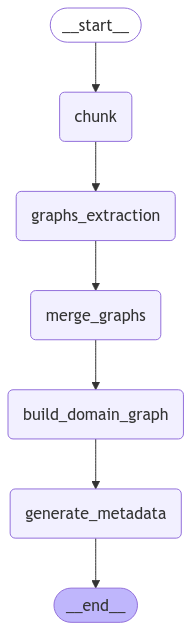

In [23]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

# Local Graph Merge

In [24]:
from typing import Any, Dict, List, Optional
from pydantic import BaseModel, Field

class LocalMetadata(BaseModel):
  section: str = Field(
    ..., description="Section Id associated with the text chunk"
  )
  subsections: List[str] = Field(
    ..., description="Sub Section Id associated with the text chunk"
  )

  class Config:
    populate_by_name = True


class LocalNode(BaseModel):
  id: str = Field(..., description="Unique identifier for the node")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the node"
  )
  type_: str = Field("", alias="type", description="Type of the node, in CamelCase")
  metadata: Dict[str, Any] = Field(
    {}, description="Metadata for the node"
  )

  class Config:
    populate_by_name = True


class LocalEdge(BaseModel):
  from_: str = Field(..., alias="from", description="Origin node ID")
  to: str = Field(..., description="Destination node ID")
  relationship: str = Field(..., description="Name of relationship between the nodes, in SNAKE_CASE")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the edge"
  )
  metadata: Dict[str, Any] = Field(
    {}, description="Metadata for the node"
  )

  class Config:
    populate_by_name = True


class LocalGraph(BaseModel):
  """Generate a knowledge graph with entities and relationships.
  """

  metadata: LocalMetadata = Field(..., description="Metadata for the knowledge graph")
  nodes: List[LocalNode] = Field(..., description="List of nodes in the knowledge graph")
  edges: List[LocalEdge] = Field(..., description="List of edges in the knowledge graph")

  class Config:
    populate_by_name = True

In [25]:
from typing import List, Tuple
def create_staging_from_extracted_data(extracts: List[Type[BaseModel]]) -> Tuple[List[LocalNode], List[LocalEdge]]:
  staging_nodes = []
  staging_edges = []

  for ext in extracts:
    chunk_str = KnowledgeGraphYAMLExporter().to_yaml(ext)
    section = yaml.safe_load(chunk_str)
    metadata = section.get('metadata', {})

    # Parse nodes
    for node_data in section.get('nodes', []):
      extracted_id = node_data['id']
      node_type = node_data['type']
      properties = node_data.get('properties', {})

      # Create node using model_validate
      node_obj = LocalNode.model_validate({
        "id": extracted_id,
        "type": node_type,  # Using "type" instead of "type_"
        "properties": properties,
        "metadata": {
          'section': metadata.get('section'),
          'subsections': metadata.get('subsections')
        }
      })

      staging_nodes.append(node_obj)

    # Parse edges
    for edge_data in section.get('edges', []):
      from_id = edge_data['from']
      to_id = edge_data['to']
      relationship = edge_data['relationship']
      properties = edge_data.get('properties', {})

      # Create edge using model_validate
      edge_obj = LocalEdge.model_validate({
        "from": from_id,  # Using "from" instead of "from_"
        "to": to_id,
        "relationship": relationship,
        "properties": properties,
        "metadata": {
          'section': metadata.get('section'),
          'subsections': metadata.get('subsections')
        }
      })

      staging_edges.append(edge_obj)
  print(staging_nodes, staging_edges)
  return staging_nodes, staging_edges

In [26]:
def create_staging_from_extracted_metadata(ext: Type[BaseModel]) -> Tuple[List[LocalNode], List[LocalEdge]]:
  staging_nodes = []
  staging_edges = []

  metadata_str = KnowledgeGraphYAMLExporter().to_yaml(ext)
  metadata = dict(yaml.safe_load(metadata_str))

  # Parse nodes
  for node_data in metadata.get('nodes', []):
    extracted_id = node_data['id']
    node_type = node_data.get('type', 'Metadata')
    properties = node_data.get('properties', {})

    # Create node using model_validate
    node_obj = LocalNode.model_validate({
      "id": extracted_id,
      "type": node_type,  # Using "type" instead of "type_"
      "properties": properties
    })

    staging_nodes.append(node_obj)

  # Parse edges
  for edge_data in metadata.get('edges', []):
    from_id = edge_data['from']
    to_id = edge_data['to']
    relationship = edge_data['relationship']
    properties = edge_data.get('properties', {})

    # Create edge using model_validate
    edge_obj = LocalEdge.model_validate({
      "from": from_id,  # Using "from" instead of "from_"
      "to": to_id,
      "relationship": relationship,
      "properties": properties
    })

    staging_edges.append(edge_obj)

  return staging_nodes, staging_edges

In [27]:
from typing import Dict, List, Any, Union
import re
from datetime import datetime

class PropertyNormalizer:
    def __init__(self):
        self.unknown_values = {'<UNKNOWN>', 'UNKNOWN', 'N/A', 'None', ''}

    def normalize_property_value(self, value: Any) -> Any:
        if isinstance(value, str):
            # Handle unknown values
            if value.strip() in self.unknown_values:
                return None

            # Try date conversion
            # date_value = self.try_parse_date(value)
            # if date_value:
            #     return date_value

            # Try numeric conversion
            numeric_value = self.try_parse_numeric(value)
            if numeric_value is not None:
                return numeric_value

            # Clean text
            return self.clean_text(value)

        return value

    def try_parse_date(self, value: str) -> Union[datetime, None]:
        date_patterns = [
            r'\d{4}-\d{2}-\d{2}',
            r'\d{2}/\d{2}/\d{4}',
            r'\d{4}'  # Year only
        ]

        for pattern in date_patterns:
          match = re.search(pattern, value)
          if match:
            try:
              date_str = match.group()
              if len(date_str) == 4:  # Year only
                  return datetime.strptime(date_str, '%Y')
              elif '-' in date_str:
                  return datetime.strptime(date_str, '%Y-%m-%d')
              else:
                  return datetime.strptime(date_str, '%m/%d/%Y')
            except ValueError:
              continue
        return None

    def try_parse_numeric(self, value: str) -> Union[float, int, None]:
        # Remove common non-numeric characters
        clean_value = re.sub(r'[,$%]', '', value)

        try:
            if '.' in clean_value:
                return float(clean_value)
            numeric_value = int(clean_value)
            return numeric_value
        except ValueError:
            return None

    def clean_text(self, text: str) -> str:
        # Remove extra whitespace
        text = ' '.join(text.split())
        # Remove special characters but keep basic punctuation
        text = re.sub(r'[^\w\s.,;!?-]', '', text)
        return text.strip()

    def normalize_properties(self, properties: Dict[str, Any]) -> Dict[str, Any]:
        normalized = {}

        for key, value in properties.items():
            # Normalize key names
            clean_key = re.sub(r'([A-Z])', r'_\1', key).lower().strip('_')

            # Normalize values
            normalized_value = self.normalize_property_value(value)

            if normalized_value is not None:
                normalized[clean_key] = normalized_value

        return normalized

def normalize_graph_data(nodes: List[LocalNode], edges: List[LocalEdge]):
    normalizer = PropertyNormalizer()

    # Normalize node properties
    for node in nodes:
        node.properties = normalizer.normalize_properties(node.properties)
        if node.metadata:
            node.metadata = normalizer.normalize_properties(node.metadata)

    # Normalize edge properties
    for edge in edges:
        edge.properties = normalizer.normalize_properties(edge.properties)
        if edge.metadata:
            edge.metadata = normalizer.normalize_properties(edge.metadata)

    return nodes, edges

In [28]:
from transformers import AutoTokenizer, AutoModel
import torch
from typing import List, Dict, Tuple, Set
import logging
from dataclasses import asdict
import json
import unicodedata
from typing import Dict, Any

class BERTResolver:
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2'):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.similarity_threshold = 0.93
        self.type_groups = {}
        self.relationship_groups = {}
        self.id_map = {}  # Global id_map for tracking all node merges

        # Setup logging
        self.logger = logging.getLogger('BERTResolver')
        self.logger.setLevel(logging.INFO)

        # Create file handlers for different log types
        self.setup_loggers()

    def setup_loggers(self):
        # Merged nodes logger
        merged_handler = logging.FileHandler('merged_nodes.json', mode='w')
        self.merged_logger = logging.getLogger('merged_nodes')
        self.merged_logger.setLevel(logging.INFO)
        self.merged_logger.addHandler(merged_handler)

        # Unmerged nodes logger
        unmerged_handler = logging.FileHandler('unmerged_nodes.json', mode='w')
        self.unmerged_logger = logging.getLogger('unmerged_nodes')
        self.unmerged_logger.setLevel(logging.INFO)
        self.unmerged_logger.addHandler(unmerged_handler)

        # Resolution metrics logger
        metrics_handler = logging.FileHandler('resolution_metrics.json', mode='w')
        self.metrics_logger = logging.getLogger('resolution_metrics')
        self.metrics_logger.setLevel(logging.INFO)
        self.metrics_logger.addHandler(metrics_handler)

    def log_node_comparison(self, node1: LocalNode, node2: LocalNode,
                       similarity: float, threshold: float, merged: bool):
        """Log detailed comparison information with threshold"""
        comparison_data = {
            'node1': {
                'id': node1.id,
                'type': node1.type_,
                'properties': node1.properties
            },
            'node2': {
                'id': node2.id,
                'type': node2.type_,
                'properties': node2.properties
            },
            'similarity_score': similarity,
            'threshold': threshold,
            'merged': merged,
            'timestamp': datetime.now().isoformat()
        }

        if merged:
            self.merged_logger.info(json.dumps(comparison_data))
        else:
            self.unmerged_logger.info(json.dumps(comparison_data))

    def log_resolution_metrics(self, type_: str, initial_count: int, final_count: int, merges: List[Dict]):
        """Log resolution metrics for a type group"""
        metrics = {
            'node_type': type_,
            'initial_count': initial_count,
            'final_count': final_count,
            'merge_count': initial_count - final_count,
            'merge_percentage': ((initial_count - final_count) / initial_count) * 100 if initial_count > 0 else 0,
            'merges': merges,
            'timestamp': datetime.now().isoformat()
        }
        self.metrics_logger.info(json.dumps(metrics))

    def get_embeddings(self, text: str) -> torch.Tensor:
        tokens = self.tokenizer(text, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            outputs = self.model(**tokens)
        return outputs.last_hidden_state.mean(dim=1)

    def group_by_type(self, nodes: List[LocalNode]):
        """Group nodes by their type, maintaining original order"""
        self.type_groups.clear()
        for node in nodes:
            if node.type_ not in self.type_groups:
                self.type_groups[node.type_] = []
            self.type_groups[node.type_].append(node)

    def group_by_relationship(self, edges: List[LocalEdge]):
        self.relationship_groups.clear()
        for edge in edges:
            if edge.relationship not in self.relationship_groups:
                self.relationship_groups[edge.relationship] = []
            self.relationship_groups[edge.relationship].append(edge)

    def normalize_text(self, text: str) -> str:
        """
        Comprehensive text normalization that:
        1. Handles unicode variations
        2. Preserves meaningful characters
        3. Normalizes whitespace
        """
        if not isinstance(text, str):
            text = str(text)

        # Convert to NFKC normalized form (handles complex unicode)
        text = unicodedata.normalize('NFKC', text)

        # Convert to lowercase for comparison
        text = text.lower()

        # Replace various types of quotes and apostrophes with standard ones
        quotes_map = {
            '"': '"',  # double quotes
            '"': '"',
            '"': '"',
            ''': "'",  # single quotes
            ''': "'",
            '`': "'",
            '´': "'",
        }
        for char, replacement in quotes_map.items():
            text = text.replace(char, replacement)

        # Handle special characters while preserving meaningful ones
        # Keep alphanumeric, preserve certain punctuation
        chars = []
        for char in text:
            if char.isalnum():
                chars.append(char)
            elif char in ".-/":  # Preserve meaningful separators
                chars.append(" ")
            elif char.isspace():
                chars.append(" ")
            # Ignore other special characters

        # Normalize whitespace
        text = ''.join(chars)
        text = ' '.join(text.split())

        return text.strip()

    def compute_node_signature(self, node: LocalNode) -> torch.Tensor:
        values = []
        for v in node.properties.values():
            if v and not isinstance(v, bool):  # Exclude empty values and booleans
                norm_value = self.normalize_text(str(v))
                if norm_value:
                    values.append(norm_value)

        signature_parts = [
            f"Type: {node.type_}",  # Type is important
            "Values: " + " | ".join(values)  # Focus on actual values
        ]

        full_text = " ".join(signature_parts)
        return self.get_embeddings(full_text)

    def compute_similarity(self, emb1: torch.Tensor, emb2: torch.Tensor) -> float:
        return torch.cosine_similarity(emb1, emb2, dim=1).item()

    def merge_properties(self, props1: Dict, props2: Dict) -> Dict:
        """Merge properties with proper handling of merged_ids"""
        merged = props1.copy()

        # Handle special _merged_ids property
        merged_ids = set(props1.get('_merged_ids', []))
        merged_ids.update(props2.get('_merged_ids', []))
        if merged_ids:
            merged['_merged_ids'] = list(merged_ids)

        # Merge other properties
        for k, v2 in props2.items():
            if k != '_merged_ids':  # Skip _merged_ids as it's handled above
                if k not in merged or not merged[k]:
                    merged[k] = v2
                elif v2 and len(str(v2)) > len(str(merged[k])):
                    merged[k] = v2

        return merged


    def update_edge_references(self, edge_id: str, removed_id: str) -> str:
        """Update edge endpoint references based on node merges"""
        return self.id_map.get(edge_id, edge_id)

    def get_dynamic_threshold(self, node1_props: Dict[str, Any], node2_props: Dict[str, Any]) -> float:
        """
        Get dynamic threshold based on:
        1. Property overlap
        2. Text length/complexity
        3. Value patterns
        """
        base_threshold = self.similarity_threshold

        # Get normalized property values
        values1 = {k: self.normalize_text(str(v))
                  for k, v in node1_props.items()
                  if v is not None and k != '_uid_'}
        values2 = {k: self.normalize_text(str(v))
                  for k, v in node2_props.items()
                  if v is not None and k != '_uid_'}

        # Calculate property overlap ratio
        common_keys = set(values1.keys()) & set(values2.keys())
        total_keys = set(values1.keys()) | set(values2.keys())
        overlap_ratio = len(common_keys) / len(total_keys) if total_keys else 0

        # Adjust threshold based on overlap
        if overlap_ratio > 0.7:  # High property overlap
            threshold_adjustment = -0.05
        elif overlap_ratio < 0.3:  # Low property overlap
            threshold_adjustment = +0.05
        else:
            threshold_adjustment = 0

        # Consider text length/complexity
        avg_length1 = sum(len(v) for v in values1.values()) / len(values1) if values1 else 0
        avg_length2 = sum(len(v) for v in values2.values()) / len(values2) if values2 else 0

        # More lenient for very short texts
        if avg_length1 < 10 and avg_length2 < 10:
            threshold_adjustment -= 0.03

        return max(0.75, min(0.98, base_threshold + threshold_adjustment))

    def resolve_nodes(self, nodes: List[LocalNode]) -> List[LocalNode]:
        """Resolve nodes with merged node tracking"""
        self.logger.info(f"Starting node resolution with {len(nodes)} nodes")

        self.group_by_type(nodes)
        resolved_nodes = []
        processed_ids = set()
        self.id_map.clear()

        for type_, type_nodes in self.type_groups.items():
            initial_count = len(type_nodes)

            # Group nodes that should be merged
            node_groups = []  # List to hold groups of nodes that should be merged
            current_group = []

            node_embeddings = []
            for node in type_nodes:
                if node.id not in processed_ids:
                    emb = self.compute_node_signature(node)
                    node_embeddings.append((node, emb))

            i = 0
            while i < len(node_embeddings):
                node1, emb1 = node_embeddings[i]

                if node1.id in processed_ids:
                    i += 1
                    continue

                # Start new group with this node
                current_group = [node1]
                merged_props = node1.properties.copy()
                merged_ids = [node1.id]

                j = i + 1
                while j < len(node_embeddings):
                    node2, emb2 = node_embeddings[j]

                    if node2.id not in processed_ids:
                        similarity = self.compute_similarity(emb1, emb2)
                        threshold = self.get_dynamic_threshold(node1.properties, node2.properties)

                        self.log_node_comparison(
                            node1, node2, similarity,
                            threshold,
                            similarity >= threshold
                        )

                        if similarity >= threshold:
                            self.logger.info(
                                f"Merging nodes: {node2.id} into {node1.id} "
                                f"(similarity: {similarity:.4f}, threshold: {threshold})"
                            )
                            current_group.append(node2)
                            merged_props = self.merge_properties(merged_props, node2.properties)
                            merged_ids.append(node2.id)
                            processed_ids.add(node2.id)

                    j += 1

                # Store the merged ids regardless of merging
                if merged_ids:
                    merged_props['_merged_ids'] = merged_ids

                # Create merged node
                merged_node = node1.__class__(
                    id=node1.id,
                    type_=node1.type_,
                    properties=merged_props,
                    metadata=node1.metadata
                )

                resolved_nodes.append(merged_node)
                processed_ids.add(node1.id)

                # Map all merged IDs to the primary node
                for merged_id in merged_ids:
                    self.id_map[merged_id] = node1.id

                i += 1

        # Debug information
        print("\nResolved nodes:")
        for node in resolved_nodes:
            print(f"Node: {node.id}")
            print(f"Merged IDs: {node.properties.get('_merged_ids', [])}")
            print(f"Properties: {node.properties}")
            print("---")

        return resolved_nodes


    def resolve_edges(self, edges: List[LocalEdge]) -> List[LocalEdge]:
        self.group_by_relationship(edges)
        resolved_edges = []
        edge_signatures = set()

        for rel_type, rel_edges in self.relationship_groups.items():
            for edge in rel_edges:
                # Update both endpoints using the id_map
                from_id = self.update_edge_references(edge.from_, edge.from_)
                to_id = self.update_edge_references(edge.to, edge.to)

                # Create unique signature for deduplication
                edge_sig = f"{from_id}|{rel_type}|{to_id}"

                if edge_sig not in edge_signatures:
                    new_edge = LocalEdge(
                        from_=from_id,
                        to=to_id,
                        relationship=rel_type,
                        properties=edge.properties.copy(),
                        metadata=edge.metadata.copy()
                    )
                    resolved_edges.append(new_edge)
                    edge_signatures.add(edge_sig)
                else:
                    # If edge exists, merge properties with existing edge
                    existing_edge = next(e for e in resolved_edges
                                      if f"{e.from_}|{e.relationship}|{e.to}" == edge_sig)
                    existing_edge.properties = self.merge_properties(
                        existing_edge.properties,
                        edge.properties
                    )

        return resolved_edges

def resolve_with_bert(nodes: List[LocalNode], edges: List[LocalEdge]) -> Tuple[List[LocalNode], List[LocalEdge]]:
    resolver = BERTResolver()
    resolved_nodes = resolver.resolve_nodes(nodes)
    resolved_edges = resolver.resolve_edges(edges)
    return resolved_nodes, resolved_edges

# Ingestion to Staging DB

In [29]:
import yaml
from typing import Dict, List, Any, Optional
import uuid

class Neo4jStagingManager:
    def __init__(self, staging_label: str = "Staging", is_staging=True):
        self.staging_label = staging_label
        self.is_staging = True

    def cleanup_staging(self) -> str:
        return f"MATCH (n:{self.staging_label}) DETACH DELETE n;"

    def get_staging_label(self) -> str:
        return self.staging_label

In [70]:
class Neo4jSchemaGenerator:
    def __init__(self, ontology: Dict[str, Any], staging_manager: Neo4jStagingManager):
        self.ontology = ontology
        self.staging_manager = staging_manager
        self.UID_FIELD = '_uid_'
        self._constraints_cache = None

    def generate_constraints(self, is_staging: bool = True) -> List[str]:
      constraints = []
      staging_label = self.staging_manager.get_staging_label() if is_staging else ""

      # For staging graphs, only create non-unique indexes
      if is_staging:
          for entity_name, entity_def in self.ontology.get('entities', {}).items():
              properties = entity_def.get('properties', {})
              for prop_name, prop_def in properties.items():
                  if self._should_create_index(entity_name, prop_name, prop_def):
                      constraints.append(
                          self._create_index_stmt(entity_name, prop_name, staging_label)
                      )
          return constraints

      # For production, create unique constraints
      for entity_name, entity_def in self.ontology.get('entities', {}).items():
          properties = entity_def.get('properties', {})
          for prop_name, prop_def in properties.items():
              if self._should_create_constraint(prop_name, prop_def):
                  constraints.append(
                      self._create_constraint_stmt(entity_name, prop_name, staging_label)
                  )
      constraints.append(
          self._create_constraint_stmt(entity_name, self.UID_FIELD, staging_label)
      )
      return constraints

    def _should_create_constraint(self, prop_name: str, prop_def: Dict) -> bool:
        if isinstance(prop_def, dict):
            return prop_def.get('unique', False) or prop_def.get('required', False)
        return False

    def _create_constraint_stmt(self, entity: str, prop: str, staging_label: str) -> str:
        prefix = f"staging_{entity.lower()}" if staging_label else entity.lower()
        labels = f"{entity}" if not staging_label else f"{entity}:{staging_label}"
        return f"""CREATE CONSTRAINT {prefix}_{prop}
                  IF NOT EXISTS FOR (n:{entity})
                  REQUIRE n.{prop} IS UNIQUE;"""

    def generate_indexes(self, is_staging: bool = True) -> List[str]:
        indexes = []
        staging_label = self.staging_manager.get_staging_label() if is_staging else ""

        for entity_name, entity_def in self.ontology.get('entities', {}).items():
            properties = entity_def.get('properties', {})
            for prop_name, prop_def in properties.items():
                if self._should_create_index(entity_name, prop_name, prop_def):
                    indexes.append(
                        self._create_index_stmt(entity_name, prop_name, staging_label)
                    )
        return indexes

    def _should_create_index(self, entity: str, prop: str, prop_def: Dict) -> bool:
        return prop_def.get('index', False) or (prop in ['type', 'name', 'id'])

    def _has_constraint(self, entity: str, prop: str) -> bool:
        return any(prop in c for c in self.generate_constraints())

    def _create_index_stmt(self, entity: str, prop: str, staging_label: str) -> str:
        prefix = f"staging_{entity.lower()}" if staging_label else entity.lower()
        labels = f"{entity}" if not staging_label else f"{entity}:{staging_label}"
        return f"""CREATE INDEX {prefix}_{prop}_idx
                  IF NOT EXISTS FOR (n:{entity})
                  ON (n.{prop});"""

In [73]:
import traceback
from collections import defaultdict

class Neo4jIngestionGenerator:
  def __init__(self, ontology: Dict[str, Any], staging_manager: Neo4jStagingManager):
    self.staging_manager = staging_manager
    self.ontology = ontology
    self.UID_FIELD = '_uid_'

  def generate_node_creation(self, nodes: List[LocalNode]) -> List[str]:
    statements = []
    nodes_by_type = defaultdict(list)
    staging_label = self.staging_manager.get_staging_label()

    for node in nodes:
        nodes_by_type[node.type_].append(node)

    for node_type, type_nodes in nodes_by_type.items():
        entity_def = self.ontology.get('entities', {}).get(node_type, {})
        unique_props = self._get_unique_properties(node_type)

        for node in type_nodes:
            props = node.properties.copy()
            if '_uid_' not in props:
                props['_uid_'] = str(uuid.uuid4())

            props_str = ", ".join(f"{k}: {self._sanitize_value(v)}" for k, v in props.items())

            if unique_props and any(prop in props for prop in unique_props):
                unique_prop = next(prop for prop in unique_props if prop in props)
                stmt = f"""
                MERGE (n:{node_type}:{staging_label} {{{unique_prop}: {self._sanitize_value(props[unique_prop])}}})
                ON CREATE SET n = {{{props_str}}}
                ON MATCH SET n = {{{props_str}}}"""
            else:
                stmt = f"CREATE (n:{node_type}:{staging_label} {{{props_str}}})"

            stmt += f"\nRETURN {self._sanitize_value(node.id + ': ')} + n._uid_ as result;"
            statements.append(stmt)

    return statements

  def generate_relationship_creation(self, nodes: List[LocalNode], edges: List[LocalEdge]) -> List[str]:
    statements = []
    node_uid_map = {}
    staging_label = self.staging_manager.get_staging_label()

    for node in nodes:
        if '_uid_' in node.properties:
            node_uid_map[node.id] = (node.properties['_uid_'], node.type_)
            if '_merged_ids' in node.properties:
                merged = node.properties['_merged_ids']
                if isinstance(merged, str):
                    merged = merged.split(',')
                for mid in merged:
                    node_uid_map[mid.strip()] = (node.properties['_uid_'], node.type_)

    for edge in edges:
        source_info = node_uid_map.get(edge.from_)
        target_info = node_uid_map.get(edge.to)

        if source_info and target_info:
            entity_def = self.ontology.get('entities', {}).get(source_info[1], {})
            relationships = entity_def.get('relationships', {})

            if edge.relationship in relationships:
                target_type = relationships[edge.relationship].get('target')
                if target_type == target_info[1]:
                    stmt = f"""
                    MATCH (source:{source_info[1]}:{staging_label}), (target:{target_info[1]}:{staging_label})
                    WHERE source._uid_ = '{source_info[0]}'
                    AND target._uid_ = '{target_info[0]}'
                    MERGE (source)-[:{edge.relationship}]->(target);"""
                    statements.append(stmt)

    return statements

  def _generate_section_node(self, node: LocalNode) -> str:
      """Generate creation statement for section nodes with mandatory properties"""
      props = node.properties.copy()
      entity_def = self.ontology.get('entities', {}).get(node.type_, {})
      required_props = {
          name: prop_def for name, prop_def in entity_def.get('properties', {}).items()
          if isinstance(prop_def, dict) and prop_def.get('required', False)
      }

      # Validate required properties
      for prop_name in required_props:
          if prop_name not in props:
              raise ValueError(f"Missing required property {prop_name} for {node.type_}")

      if '_uid_' not in props:
          props['_uid_'] = str(uuid.uuid4())

      props_str = ", ".join(f"{k}: {self._sanitize_value(v)}" for k, v in props.items())
      return f"CREATE (n:{node.type_} {{{props_str}}}) RETURN {self._sanitize_value(node.id + ': ')} + n._uid_ as result;"

  def _generate_subsection_node(self, node: LocalNode) -> str:
      """Generate creation statement for subsection nodes with parent validation"""
      props = node.properties.copy()
      entity_def = self.ontology.get('entities', {}).get(node.type_, {})

      # Add unique constraint handling
      unique_props = {
          name: prop_def for name, prop_def in entity_def.get('properties', {}).items()
          if isinstance(prop_def, dict) and prop_def.get('unique', False)
      }

      if '_uid_' not in props:
          props['_uid_'] = str(uuid.uuid4())

      if unique_props and any(prop in props for prop in unique_props):
          unique_prop = next(prop for prop in unique_props if prop in props)
          props_str = ", ".join(f"{k}: {self._sanitize_value(v)}" for k, v in props.items())
          return f"""
          MERGE (n:{node.type_} {{{unique_prop}: {self._sanitize_value(props[unique_prop])}}})
          ON CREATE SET n = {{{props_str}}}
          ON MATCH SET n = {{{props_str}}}
          RETURN {self._sanitize_value(node.id + ': ')} + n._uid_ as result;
          """

      props_str = ", ".join(f"{k}: {self._sanitize_value(v)}" for k, v in props.items())
      return f"CREATE (n:{node.type_} {{{props_str}}}) RETURN {self._sanitize_value(node.id + ': ')} + n._uid_ as result;"

  def _belongs_to_section(self, node: LocalNode, section_node: LocalNode) -> bool:
      """Validate if node belongs to section based on ontology and metadata"""
      section_def = self.ontology.get('entities', {}).get(section_node.type_, {})
      relationships = section_def.get('relationships', {})

      # Check direct relationship in ontology
      for rel_def in relationships.values():
          if rel_def.get('target') == node.type_:
              return True

      # Check metadata-based relationship
      section_info = node.metadata.get('section') if hasattr(node, 'metadata') else None
      if section_info and section_info == section_node.type_:
          return True

      # Check nested relationships
      for rel_name, rel_def in relationships.items():
          target_type = rel_def.get('target')
          if isinstance(target_type, list) and node.type_ in target_type:
              return True

      return False

  def _create_relationship_stmt(
      self, source_node: LocalNode, target_node: LocalNode,
      relationship: str, properties: Dict, staging_label: str
  ) -> str:
      """Create a single relationship statement with UID checks"""
      # Check if source and target nodes have UIDs
      source_uid = source_node.properties.get(self.UID_FIELD)
      target_uid = target_node.properties.get(self.UID_FIELD)

      if not source_uid or not target_uid:
          print(f"Warning: Missing UID for relationship {source_node.id} -> {target_node.id}")
          return None

      create_stmt = f"MERGE (source)-[r:{relationship}]->(target)"

      set_stmts = []
      if properties:
          for key, value in properties.items():
              if value is not None:
                  set_stmts.append(f"ON CREATE SET r.{key} = {self._sanitize_value(value)}")

      # Build match conditions for source and target nodes
      source_match = f"source.{self.UID_FIELD} = {self._sanitize_value(source_uid)}"
      target_match = f"target.{self.UID_FIELD} = {self._sanitize_value(target_uid)}"

      match_stmt = f"""
      MATCH (source:{source_node.type_}{staging_label})
      WHERE {source_match}
      WITH source
      MATCH (target:{target_node.type_}{staging_label})
      WHERE {target_match}
      WITH source, target
      LIMIT 1"""

      full_stmt = "\n".join([match_stmt, create_stmt] + set_stmts) + ";"
      return full_stmt

  def _get_unique_properties(self, node_type: str) -> List[str]:
    """Get unique properties for a node type from ontology"""
    entity_def = self.ontology.get('entities', {}).get(node_type, {})
    properties = entity_def.get('properties', {})

    unique_props = []
    for prop_name, prop_def in properties.items():
        if isinstance(prop_def, dict) and (
            prop_def.get('unique', False) or
            prop_def.get('required', False)
        ):
            unique_props.append(prop_name)
    return unique_props

  def _build_node_uid_map(self, nodes: List[LocalNode]):
    node_uid_map = {}
    for node in nodes:
        uid = node.properties.get('_uid_')
        if uid:
            node_uid_map[node.id] = (uid, node.type_)
            merged = node.properties.get('_merged_ids')
            if merged:
                if isinstance(merged, str):
                    merged = merged.split(',')
                for mid in merged:
                    node_uid_map[mid.strip()] = (uid, node.type_)
    return node_uid_map

  def _sanitize_value(self, value: Any) -> str:
    if isinstance(value, str):
        escaped = value.replace('\\', '\\\\').replace("'", "\\'")
        return f"'{escaped}'"
    if isinstance(value, list) or (isinstance(value, str) and ',' in value):
        return self._sanitize_value(','.join(str(x) for x in (value.split(',') if isinstance(value, str) else value)))
    if isinstance(value, bool):
        return str(value).lower()
    if value is None:
        return "null"
    return str(value)

  def create_document_node(self, doc_metadata: LocalNode, nodes: List[LocalNode]) -> List[str]:
    """Creates document node and relationships to section nodes"""
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""

    # Create document node
    doc_props = " ".join([f"SET d.{k} = {self._sanitize_value(v)}" for k, v in doc_metadata.properties.items()])
    id_prop = f"{{{self.UID_FIELD}: '{uuid.uuid4()}'}}"
    return f"CREATE (d:Document{staging_label}{id_prop}) {doc_props}" + f" RETURN 'doc_id: ' + d.{self.UID_FIELD};"

  def create_document_rels(self, doc_id: str, doc_metadata: LocalNode, nodes: List[LocalNode]) -> List[str]:
    """Creates document node and relationships to section nodes"""
    statements = []
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""
    doc_metadata_props = doc_metadata.properties
    match_props = f"n.{self.UID_FIELD} = {self._sanitize_value(doc_metadata_props['_uid_'])}"
    rel_stmt = f"""
    MATCH (d:Document{staging_label})
    WHERE d.{self.UID_FIELD} = '{doc_id}'
    WITH d
    MATCH (n:{doc_metadata.type_}{staging_label})
    WHERE {match_props}
    MERGE (d)-[r:HAS]->(n)
    SET r.section = '{doc_metadata.type_}';
    """
    statements.append(rel_stmt)
    # Create relationships to sections
    section_types = self.ontology.get('sections', {})
    for node in nodes:
        if node.type_ in section_types:
            props = node.properties
            match_props = f"n.{self.UID_FIELD} = {self._sanitize_value(props['_uid_'])}"
            rel_stmt = f"""
            MATCH (d:Document{staging_label})
            WHERE d.{self.UID_FIELD} = '{doc_id}'
            WITH d
            MATCH (n:{node.type_}{staging_label})
            WHERE {match_props}
            MERGE (d)-[r:HAS]->(n)
            SET r.section = '{node.type_}';
            """
            statements.append(rel_stmt)

    return statements

In [32]:
from neo4j import GraphDatabase

def run_cypher(query: str, **kwargs):
  with GraphDatabase.driver(NEO4J_HOST, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
    driver.verify_connectivity()
    with driver.session(database=NEO4J_DB) as session:
      result = session.run(query, **kwargs).to_df()
      return result


def run_cypher_batch(queries: List[str], **kwargs) -> List[str]:
  results = []
  for query in queries:
    print(query)
    res = run_cypher(query, **kwargs)
    results.append(res)
  return results

In [54]:
def sanitise(nodes: List[LocalNode], edges: List[LocalEdge]) -> Tuple[List[LocalNode], List[LocalEdge]]:
  normalized_nodes, normalized_edges = normalize_graph_data(nodes, edges)
  resolved_nodes, resolved_edges = resolve_with_bert(normalized_nodes, normalized_edges)
  return resolved_nodes, resolved_edges

def ingest(ontology_yaml: str,
           resolved_nodes: List[LocalNode], resolved_edges: List[LocalEdge],
           staging: Neo4jStagingManager):
    # Load ontology and initialize components
    ontology = yaml.safe_load(ontology_yaml)

    # Proceed with schema and data ingestion
    schema_gen = Neo4jSchemaGenerator(ontology, staging)
    ingestion_gen = Neo4jIngestionGenerator(ontology, staging)

    # Create schema
    staging_constraints = schema_gen.generate_constraints(staging.is_staging)
    staging_indexes = schema_gen.generate_indexes(staging.is_staging)

    # Generate and execute statements
    run_cypher_batch(staging_constraints)
    run_cypher_batch(staging_indexes)

    node_stmts = ingestion_gen.generate_node_creation(resolved_nodes)
    if node_stmts:
        nodes_with_ids = run_cypher_batch(node_stmts)
        resolved_nodes = set_node_id(nodes_with_ids, resolved_nodes)

    rel_stmts = ingestion_gen.generate_relationship_creation(resolved_nodes, resolved_edges)
    if rel_stmts:
        run_cypher_batch(rel_stmts)

    return resolved_nodes, resolved_edges

def create_document(ontology_yaml:str, metadata: LocalNode,
                    nodes: List[LocalNode], staging: Neo4jStagingManager):
  ontology = yaml.safe_load(ontology_yaml)
  ingestion_gen = Neo4jIngestionGenerator(ontology, staging)
  stmt = ingestion_gen.create_document_node(metadata, nodes)
  doc_ids = run_cypher_batch([stmt])
  doc_id = doc_ids[0].iat[0, 0].split(': ')[1]
  stmts = ingestion_gen.create_document_rels(doc_id, metadata, nodes)
  run_cypher_batch(stmts)


def group_data_by_section(data: List[List[Type[BaseModel]]]) -> Dict[str, List[Type[BaseModel]]]:
  grouped_data = {}
  for items in data:
    for item in items:
      section = item.metadata.section
      if section not in grouped_data:
        grouped_data[section] = []
      grouped_data[section].append(item)
  return grouped_data

In [60]:
def set_node_id(nodes_with_ids, resolved_nodes: List[LocalNode]):
    # Create mapping of node IDs to UIDs from the results
    id_to_uid = {}
    for result in nodes_with_ids:
        if result is not None and len(result) > 0:
            id_mapping = result.at[0, 'result']
            if id_mapping:
                node_id, uid = id_mapping.split(': ')
                id_to_uid[node_id] = uid

    # Update nodes with mapped UIDs
    for node in resolved_nodes:
        if node.id in id_to_uid:
            node.properties['_uid_'] = id_to_uid[node.id]
        else:
            node.properties['_uid_'] = str(uuid.uuid4())

        # Map merged IDs
        if '_merged_ids' in node.properties:
            merged = node.properties['_merged_ids']
            if isinstance(merged, str):
                merged = merged.split(',')
            for mid in merged:
                id_to_uid[mid.strip()] = node.properties['_uid_']

    return resolved_nodes

In [35]:
def sanitise_and_ingest(ontology: str, metadata: List[Type[BaseModel]],
                        data: List[List[Type[BaseModel]]], staging: Neo4jStagingManager) -> str:
    # Convert metadata to nodes and edges
    metadata_nodes, metadata_edges = create_staging_from_extracted_metadata(metadata)

    # Group data by section and process each section
    grouped_data = group_data_by_section(data)
    section_nodes = []
    section_edges = []

    # Process each section maintaining merge info
    for section, section_data in grouped_data.items():
        nodes, edges = create_staging_from_extracted_data(section_data)
        # Process section-level merges
        resolved_nodes, resolved_edges = sanitise(nodes, edges)
        section_nodes.extend(resolved_nodes)
        section_edges.extend(resolved_edges)

    # Combine metadata with section data
    all_nodes = metadata_nodes + section_nodes
    all_edges = metadata_edges + section_edges

    # Create node mapping including all merged IDs
    node_map = {}
    for node in all_nodes:
        node_map[node.id] = node
        for id_field in ['_merged_ids', 'merged_ids']:
            merged = node.properties.get(id_field)
            if merged:
                if isinstance(merged, str):
                    merged = [m.strip() for m in merged.split(',')]
                for merged_id in merged:
                    node_map[merged_id] = node

    # Deduplicate nodes preserving merge history
    final_nodes = []
    seen_ids = set()

    for node in all_nodes:
        base_node = node_map.get(node.id)
        if base_node and base_node.id not in seen_ids:
            final_nodes.append(base_node)
            seen_ids.add(base_node.id)
            # Add all merged IDs to seen set
            for id_field in ['_merged_ids', 'merged_ids']:
                merged = base_node.properties.get(id_field)
                if merged:
                    if isinstance(merged, str):
                        merged = [m.strip() for m in merged.split(',')]
                    seen_ids.update(merged)

    # Process edges using node mapping
    final_edges = []
    seen_edge_sigs = set()

    for edge in all_edges:
        source = node_map.get(edge.from_)
        target = node_map.get(edge.to)

        if source and target:
            edge_sig = f"{source.id}_{edge.relationship}_{target.id}"
            if edge_sig not in seen_edge_sigs:
                final_edges.append(LocalEdge(
                    from_=source.id,
                    to=target.id,
                    relationship=edge.relationship,
                    properties=edge.properties
                ))
                seen_edge_sigs.add(edge_sig)
                print(f"Mapped edge: {source.id} -> {target.id} ({edge.relationship})")

    # Ingest final data
    ingest(ontology, final_nodes, final_edges, staging)

    # Create document relationships
    metadata_node = next((d for d in final_nodes if d.type_ == 'Metadata'), None)
    if metadata_node is not None:
        return create_document(ontology, metadata_node, final_nodes, staging)

    return None

# Run pipeline

In [74]:
from datetime import datetime
o = []
def run_pipeline(data, ontology, form10k):
  output = []
  for text in data:
    staging_id = f"Staging_{datetime.now().strftime('%Y%m%d%H%M%S')}"
    state_input = {"text": text, "ontology_str": ontology, "ontology_obj": form10k}
    result = app.invoke(state_input)
    output.append((staging_id, result))
    o = output
    sanitise_and_ingest(ontology, result['metadata'], result['domain_graphs'], Neo4jStagingManager(staging_id, is_staging=True))
  return output

In [75]:
pipeline_output = run_pipeline(all_form10k[2:3], ontology, form10k)

Chunking...
Chunking DONE
Extracting Generic Graphs in Parallel...
Extracting Generic Graph DONE
Merging Graphs...
Building Domain Graphs in Parallel...
Generating Metadata
[LocalNode(id='PartI', properties={}, type_='PartI', metadata={'section': 'PartI', 'subsections': ['Business']}), LocalNode(id="Alexander's_Business", properties={'description': 'A REIT focused on leasing, managing, developing, and redeveloping properties in New York, primarily managed by Vornado Realty Trust', 'employees': 0, 'seasonality': 'Real estate operations', 'regulatoryEnvironment': 'REIT regulations, commercial real estate zoning'}, type_='Business', metadata={'section': 'PartI', 'subsections': ['Business']}), LocalNode(id='AlexanderREIT_Segment', properties={'name': 'Real Estate Investment Trust (REIT)'}, type_='BusinessSegment', metadata={'section': 'PartI', 'subsections': ['Business']}), LocalNode(id='Manhattan_Property', properties={'name': '731 Lexington Avenue Property'}, type_='Product', metadata={'

INFO:BERTResolver:Starting node resolution with 20 nodes
INFO:merged_nodes:{"node1": {"id": "PartI", "type": "PartI", "properties": {}}, "node2": {"id": "PartI", "type": "PartI", "properties": {}}, "similarity_score": 0.9999999403953552, "threshold": 0.9500000000000001, "merged": true, "timestamp": "2025-01-05T07:21:00.366708"}
INFO:BERTResolver:Merging nodes: PartI into PartI (similarity: 1.0000, threshold: 0.9500000000000001)
INFO:unmerged_nodes:{"node1": {"id": "Manhattan_Property", "type": "Product", "properties": {"name": "731 Lexington Avenue Property"}}, "node2": {"id": "QueensProperties", "type": "Product", "properties": {"name": "Queens Shopping Centers and Apartment Tower"}}, "similarity_score": 0.5376026630401611, "threshold": 0.88, "merged": false, "timestamp": "2025-01-05T07:21:00.425987"}
INFO:unmerged_nodes:{"node1": {"id": "BusinessAndOperationsRisks", "type": "RiskFactor", "properties": {"name": "Business and Operations Risks", "description": "We may be adversely affec


Resolved nodes:
Node: PartI
Merged IDs: ['PartI', 'PartI']
Properties: {'_merged_ids': ['PartI', 'PartI']}
---
Node: Alexander's_Business
Merged IDs: ["Alexander's_Business"]
Properties: {'description': 'A REIT focused on leasing, managing, developing, and redeveloping properties in New York, primarily managed by Vornado Realty Trust', 'employees': 0, 'seasonality': 'Real estate operations', 'regulatory_environment': 'REIT regulations, commercial real estate zoning', '_merged_ids': ["Alexander's_Business"]}
---
Node: AlexanderREIT_Segment
Merged IDs: ['AlexanderREIT_Segment']
Properties: {'name': 'Real Estate Investment Trust REIT', '_merged_ids': ['AlexanderREIT_Segment']}
---
Node: Manhattan_Property
Merged IDs: ['Manhattan_Property']
Properties: {'name': '731 Lexington Avenue Property', '_merged_ids': ['Manhattan_Property']}
---
Node: QueensProperties
Merged IDs: ['QueensProperties']
Properties: {'name': 'Queens Shopping Centers and Apartment Tower', '_merged_ids': ['QueensProperti

# Global ER pipeline

In [ ]:
from typing import Optional, List, Dict
from dataclasses import dataclass
from neo4j import GraphDatabase

@dataclass
class DbNode:
    id: str
    labels: List[str]
    properties: Dict

@dataclass
class DbEdge:
    id: str
    type: str
    properties: Dict
    source_id: str
    target_id: str

class StagingGraphExtractor:
    def __init__(self, uri: str, username: str, password: str):
        self.driver = GraphDatabase.driver(uri, auth=(username, password))
        self.UID_FIELD = '_uid_'

    def get_subgraph(self, doc_id: str) -> tuple[List[Node], List[Edge]]:
        with self.driver.session() as session:
            # First get all nodes connected to document
            nodes_query = f"""
            MATCH (doc:Document WHERE doc.{self.UID_FIELD} = $doc_id)
            CALL apoc.path.subgraphNodes(doc, {{
                relationshipFilter: '>',
                maxLevel: 1000
            }})
            YIELD node
            RETURN collect({{node: node, {self.UID_FIELD}: node.{self.UID_FIELD}}}) as nodeWithIds
            """

            # Then get all relationships between these nodes
            rels_query = f"""
            MATCH (doc:Document WHERE doc.{self.UID_FIELD} = $doc_id)
            CALL apoc.path.subgraphAll(doc, {{
                relationshipFilter: '>',
                maxLevel: 1000
            }})
            YIELD relationships
            UNWIND relationships as rel
            RETURN collect({{rel: rel, {self.UID_FIELD}: rel.{self.UID_FIELD}, start: startNode(rel).{self.UID_FIELD}, end: endNode(rel).{self.UID_FIELD}}}) as relationshipWithIds
            """

            # Execute queries
            nodes_result = session.run(nodes_query, doc_id=doc_id)
            nodes_data = nodes_result.single()["nodeWithIds"]

            rels_result = session.run(rels_query, doc_id=doc_id)
            rels_data = rels_result.single()["relationshipWithIds"]

            # Convert to our data classes
            nodes = [
                DbNode(
                    id=n[self.UID_FIELD],
                    labels=list(n['node'].labels),
                    properties={**n['node']},  # Convert neo4j node props to dict
                )
                for n in nodes_data
            ]

            edges = [
                DbEdge(
                    id=r[self.UID_FIELD],
                    type=r['rel'].type,
                    properties={**r['rel']},  # Convert neo4j rel props to dict
                    source_id=r['start'],
                    target_id=r['end']
                )
                for r in rels_data
            ]

            return nodes, edges

    def validate_subgraph(self, nodes: List[DbNode], edges: List[DbEdge]) -> bool:
        """
        Validate that the subgraph is properly connected
        """
        # Create set of all node IDs
        node_ids = {node.id for node in nodes}

        # Check if all edge endpoints exist in nodes
        for edge in edges:
            if edge.source_id not in node_ids or edge.target_id not in node_ids:
                return False

        return True

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.driver.close()

In [ ]:
with StagingGraphExtractor(NEO4J_HOST, NEO4J_USER, NEO4J_PASSWORD) as extractor:
    doc_id = "4:93633211-0ed9-49c4-9ba7-184e29458a9e:9"
    nodes, edges = extractor.get_subgraph(doc_id)
    print(nodes, edges)
    # Validate the subgraph
    if extractor.validate_subgraph(nodes, edges):
        print(f"Retrieved valid subgraph with {len(nodes)} nodes and {len(edges)} edges")

        # Print some statistics
        label_counts = {}
        for node in nodes:
            for label in node.labels:
                label_counts[label] = label_counts.get(label, 0) + 1

        print("\nNode label distribution:")
        for label, count in label_counts.items():
            print(f"{label}: {count}")

        print("\nRelationship type distribution:")
        rel_type_counts = {}
        for edge in edges:
            rel_type_counts[edge.type] = rel_type_counts.get(edge.type, 0) + 1

        for rel_type, count in rel_type_counts.items():
            print(f"{rel_type}: {count}")
    else:
        print("Retrieved disconnected or invalid subgraph")

[DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:9', labels=['Document'], properties={'filing_date': '2023-12-31', 'name': 'Form10K_2023', 'about': 'Form 10K Annual report containing companys financial statements and operations', 'context': 'Annual report describing Adams Resources  Energys business operations including crude oil marketing, transportation, and storage services', '_id': '4:93633211-0ed9-49c4-9ba7-184e29458a9e:23', 'type': 'financial_report'}), DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:7', labels=['PartI'], properties={}), DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:23', labels=['Metadata'], properties={'name': 'Form10K_2023', 'about': 'Form 10K Annual report containing companys financial statements and operations', 'context': 'Annual report describing Adams Resources  Energys business operations including crude oil marketing, transportation, and storage services', 'type': 'financial_report', 'filing_date': '2023-12-31'}), DbNode(id='4:93633211-0ed9-49c4-